In [1]:
from ModMNIST import ModMNIST
import warnings
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torch
from tqdm import tqdm
from statistics import fmean
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

device = torch.device('cuda')

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
import sys
import os

# Get the parent directory path
parent_dir = os.path.abspath('..')

# Add the parent directory to sys.path
sys.path.append(parent_dir)

# Now you can import the parent_module
from NNUtilities import display_losses_and_accuracies, plot_clusters, set_requires_grad, plot3D_clusters

torch.manual_seed(43)

In [3]:
def imshow(img):
    npimg = img.numpy()
    plt.axis("off")
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

In [4]:
trainset = ModMNIST(train=True)
testset = ModMNIST(train=False)

BATCH_SIZE = 1024

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
labels.min(), labels.max()

(tensor(0, dtype=torch.uint8), tensor(39, dtype=torch.uint8))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


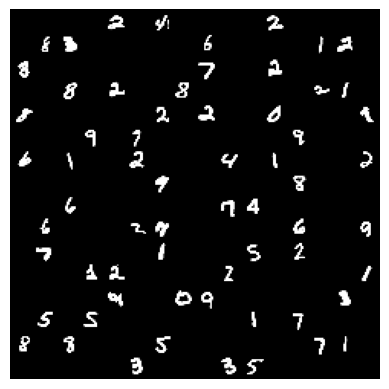

In [6]:
dataiter = trainloader.__iter__()
images, labels = dataiter.__next__()

imshow(torchvision.utils.make_grid(images[:64]))

In [7]:
OUT_CHANNELS = 10

In [8]:
def get_test_loss(model, testloader, lossfunc):
    model.eval()

    total_loss = 0

    with torch.no_grad():
        for x, y in testloader:
            x =  x.to(device)

            y = y.float()

            digit = torch.div(y, 16, rounding_mode='floor')
            pos = torch.remainder(y, 16)

            new_y = torch.vstack((digit, pos)).T

            new_y = new_y.to(device)

            out = model(x)

            l = lossfunc(out, new_y)

            total_loss += l.item()

        return float(total_loss/len(testloader.dataset))

In [9]:
def train(model, trainloader, testloader, opt, lossfunc, epochs=5):
    train_loss = []
    test_loss =  []
    for i in tqdm(range(epochs)):
        curr_train_loss = 0
        test_loss.append(get_test_loss(model, testloader, lossfunc))
        model.train()
        for x, y in trainloader:
            x =  x.to(device)

            y = y.float()

            digit = torch.div(y, 16, rounding_mode='floor')
            pos = torch.remainder(y, 16)

            new_y = torch.vstack((digit, pos)).T

            new_y = new_y.to(device)

            out = model(x)

            l = lossfunc(out, new_y)

            curr_train_loss += l.item()

            opt.zero_grad()
            l.backward()
            opt.step()
        
        train_loss.append(curr_train_loss/len(trainloader.dataset))
    
    return train_loss, test_loss


In [13]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
    
        self.conv = torch.nn.Sequential(
                torch.nn.Conv2d(in_channels=1, out_channels=OUT_CHANNELS, kernel_size=27), # torch.nn.Conv2d(in_channels=1, out_channels=10, kernel_size=14),
                torch.nn.ReLU(),
                torch.nn.Flatten()
        )
        self.head = torch.nn.Linear(OUT_CHANNELS*2*2, 2)
        
    def forward(self, x):
        return self.head(self.conv(x))
    
    '''
    
    def get_labels_and_predictions(self, dataloader):
        self.eval()
        predictions = torch.empty(len(dataloader.dataset), dtype=torch.uint8)
        labels = torch.empty(len(dataloader.dataset), dtype=torch.uint8)
        with torch.no_grad():
            for i, (x, y) in enumerate(dataloader):

                x = x.to(device)
                y = y.to(device)

                out = self(x)
                out = torch.argmax(out, axis=1)
                
                predictions[i*BATCH_SIZE:(i+1)*BATCH_SIZE] = out.cpu()
                labels[i*BATCH_SIZE:(i+1)*BATCH_SIZE] = y.cpu()
        return labels.tolist(), predictions.tolist()
    
    def get_output_embeddings(self, dataloader):
        self.eval()

        predictions = torch.empty((len(dataloader.dataset), 2))

        with torch.no_grad():
            for i, (x, _) in enumerate(dataloader):
                x = x.to(device)

                out = self(x)
                predictions[i*BATCH_SIZE:(i+1)*BATCH_SIZE, :] = out.cpu()
            
        return predictions.tolist()
    
    '''
        
        
model = CNN().to(device)

In [14]:
optimizer=torch.optim.Adam(model.parameters(), lr=1e-2)
lossfunc=torch.nn.MSELoss()

100%|██████████| 10/10 [02:34<00:00, 15.50s/it]


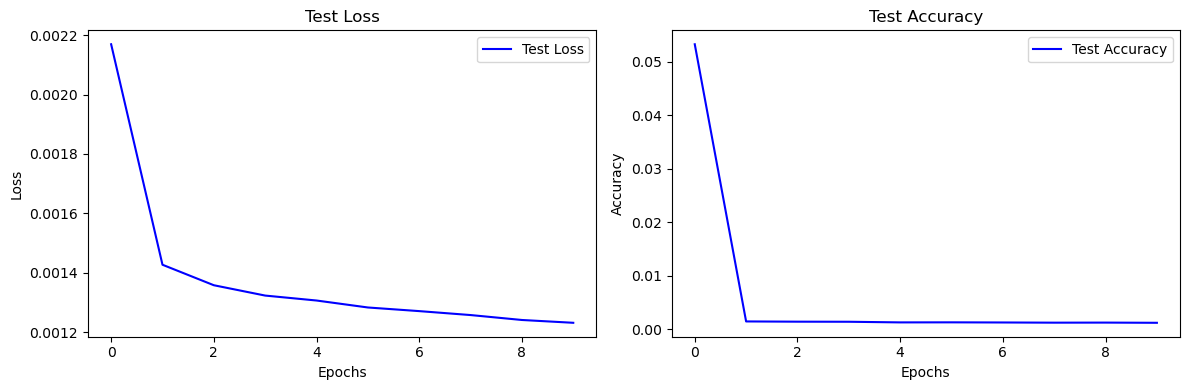

In [15]:
train_loss, test_loss = train(model=model, trainloader=trainloader, testloader=testloader, opt=optimizer, lossfunc=lossfunc, epochs=10)
display_losses_and_accuracies(loss=train_loss, accuracy=test_loss, epochs=10)

In [28]:
x, y = next(iter(testloader))

model(x.to(device))

tensor([[ 5.9003,  0.4765],
        [ 7.3270,  0.9178],
        [ 6.2912,  2.2137],
        ...,
        [ 3.0635, 12.8888],
        [ 3.4419, 13.9858],
        [ 3.3616, 14.4522]], device='cuda:0', grad_fn=<AddmmBackward0>)